<a href="https://colab.research.google.com/github/narayananxyz/deep_learning/blob/main/capstone_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Importing the necessary libraries**

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import h5py
import random
import cv2
import os

**Let us check the version of tensorflow.**

In [2]:
tf.__version__


'2.20.0'

## **Mount the drive**

Let us start by mounting the Google drive. You can run the below cell to mount the Google drive.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Let's extract the zip file. This needs to be done only once in colab as once extracted it is going to remain there.

In [12]:
#!unzip '/content/drive/MyDrive/mitcourse/capstone/Facial_emotion_images.zip' -d '/content/drive/MyDrive/mitcourse/capstone/facial+emotions'

In [4]:
base_path = '/content/drive/MyDrive/mitcourse/capstone/facial+emotions/Facial_emotion_images'
print(os.listdir(base_path))

['validation', 'test', 'train']


In [17]:
import shutil
import zipfile
import os

# Step 1 — Copy zip from Drive to local
print("Copying zip file from Drive...")
shutil.copy(
    '/content/drive/MyDrive/mitcourse/capstone/Facial_emotion_images.zip',
    '/content/Facial_emotion_images.zip'
)
print("Copy done!")

# Step 2 — Extract locally
print("Extracting...")
with zipfile.ZipFile('/content/Facial_emotion_images.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')
print("Extraction done!")

# Step 3 — Verify structure
print("\nFolder structure:")
for split in ['train', 'validation', 'test']:
    path = f'/content/Facial_emotion_images/{split}'
    if os.path.exists(path):
        print(f"  {split}: {os.listdir(path)}")

Copying zip file from Drive...
Copy done!
Extracting...
Extraction done!

Folder structure:
  train: ['sad', 'happy', 'surprise', 'neutral']
  validation: ['sad', 'happy', 'surprise', 'neutral']
  test: ['sad', 'happy', 'surprise', 'neutral']


In [18]:
# Use local path for all generators
base_path = '/content/Facial_emotion_images/'

# **Data Analysis**

Let's see how the folders are organized and access the folders from python and confirm that everything is intact.

In [19]:
# Check top level folders
print("Top level folders:")
print(os.listdir(base_path))

# Check subfolders
for split in ['train', 'validation', 'test']:
    split_path = os.path.join(base_path, split)
    print(f"\n{split} folders:")
    print(os.listdir(split_path))

Top level folders:
['validation', 'test', 'train']

train folders:
['sad', 'happy', 'surprise', 'neutral']

validation folders:
['sad', 'happy', 'surprise', 'neutral']

test folders:
['sad', 'happy', 'surprise', 'neutral']


## Count number of images from class

Let's write python to count the number of images in each class.

In [20]:
splits = ['train', 'validation', 'test']
emotions = ['happy', 'sad', 'surprise', 'neutral']

print("=== Image Count Per Class ===\n")

counts = {}
for split in splits:
    counts[split] = {}
    print(f"{split.upper()}:")
    total = 0
    for emotion in emotions:
        path = os.path.join(base_path, split, emotion)
        if os.path.exists(path):
            count = len(os.listdir(path))
            counts[split][emotion] = count
            total += count
            print(f"  {emotion:10s}: {count} images")
    print(f"  {'TOTAL':10s}: {total} images\n")

=== Image Count Per Class ===

TRAIN:
  happy     : 3976 images
  sad       : 3982 images
  surprise  : 3173 images
  neutral   : 3978 images
  TOTAL     : 15109 images

VALIDATION:
  happy     : 1825 images
  sad       : 1139 images
  surprise  : 797 images
  neutral   : 1216 images
  TOTAL     : 4977 images

TEST:
  happy     : 32 images
  sad       : 32 images
  surprise  : 32 images
  neutral   : 32 images
  TOTAL     : 128 images



## Visualize class distribution

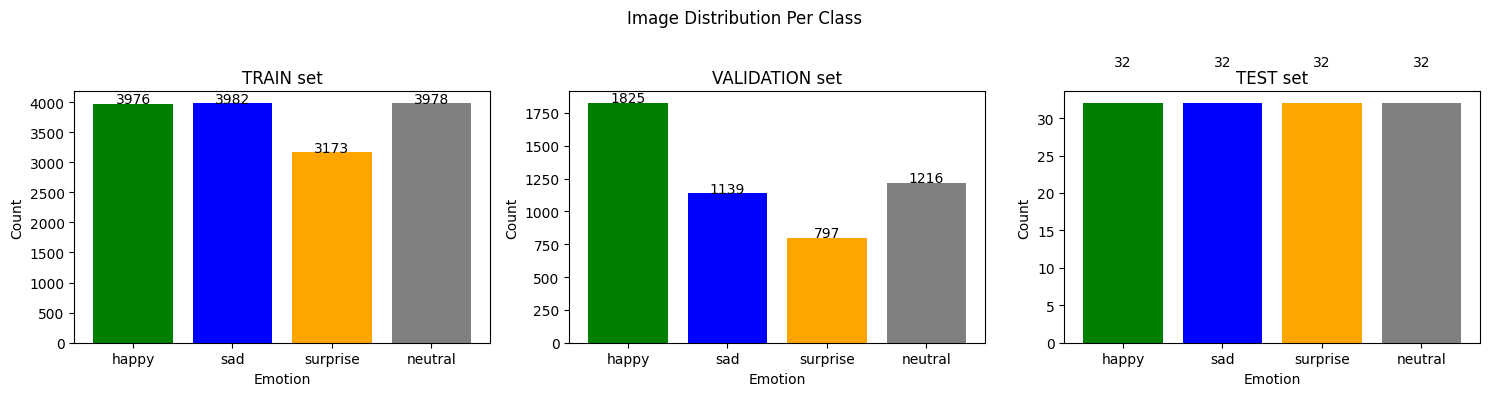

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, split in enumerate(splits):
    values = [counts[split].get(e, 0) for e in emotions]
    axes[idx].bar(emotions, values, color=['green', 'blue', 'orange', 'gray'])
    axes[idx].set_title(f'{split.upper()} set')
    axes[idx].set_xlabel('Emotion')
    axes[idx].set_ylabel('Count')
    for i, v in enumerate(values):
        axes[idx].text(i, v + 5, str(v), ha='center')

plt.suptitle('Image Distribution Per Class')
plt.tight_layout()
plt.show()

## Visualize Sample images

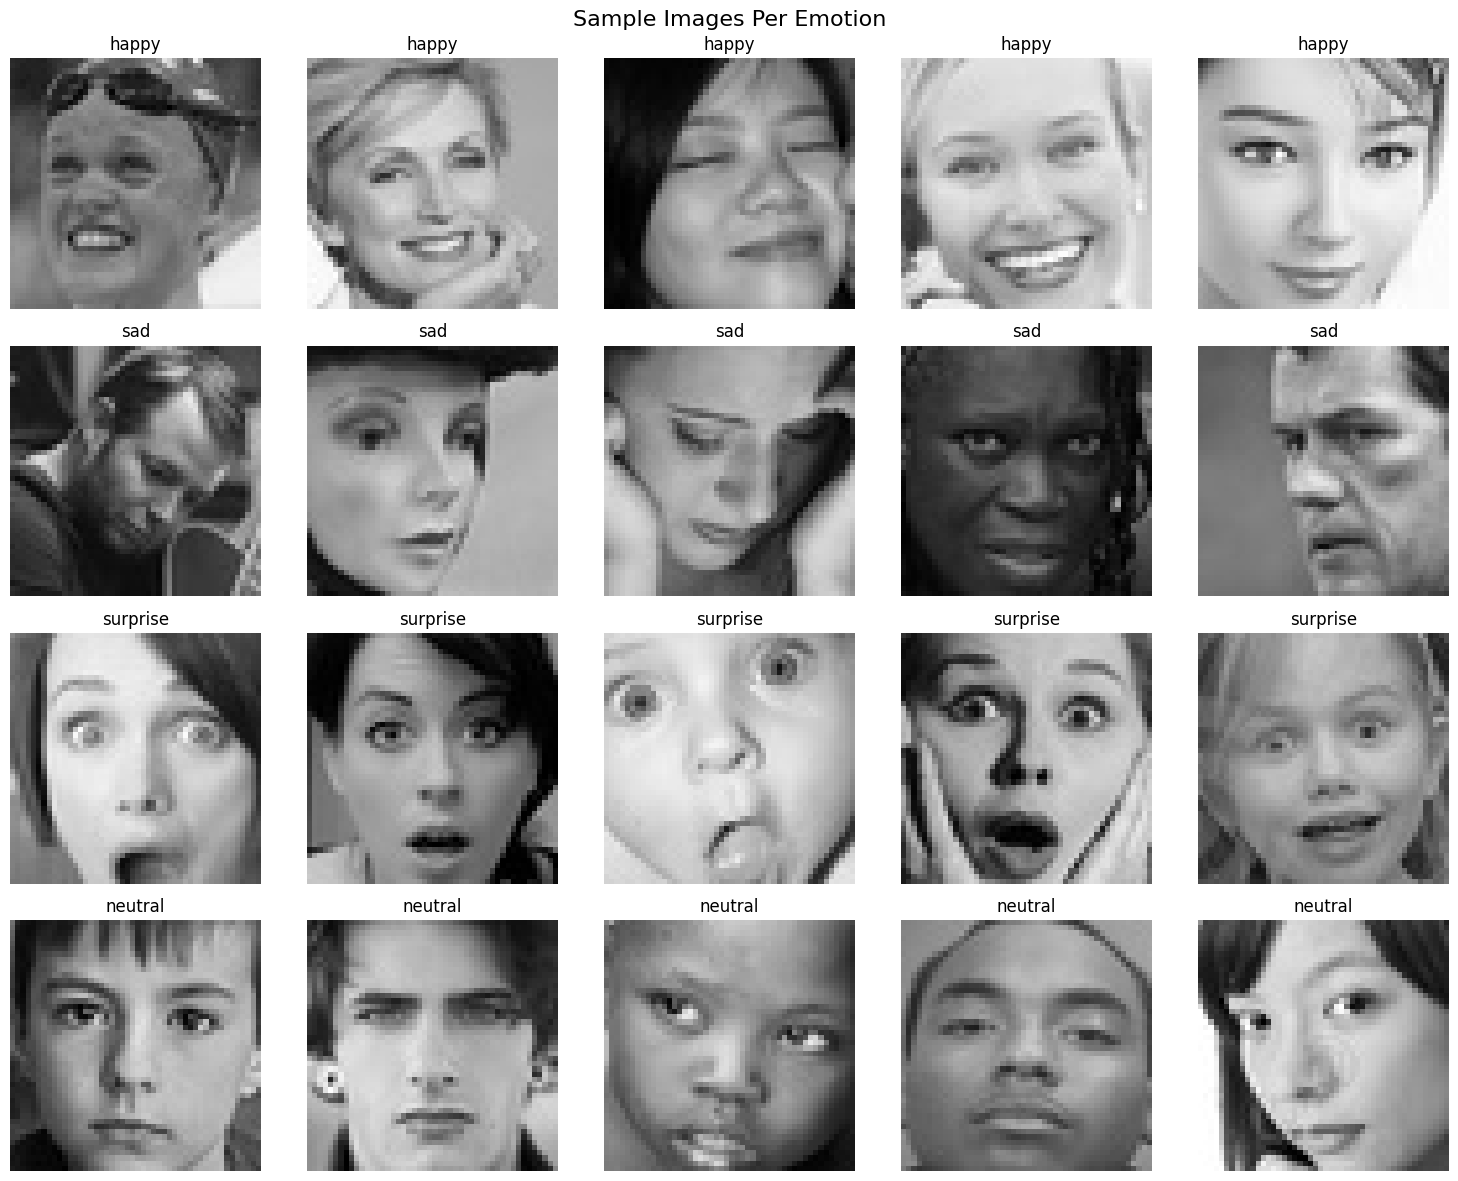

In [22]:
fig, axes = plt.subplots(4, 5, figsize=(15, 12))

for row, emotion in enumerate(emotions):
    path = os.path.join(base_path, 'train', emotion)
    images = os.listdir(path)
    samples = random.sample(images, 5)

    for col, img_name in enumerate(samples):
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[row][col].imshow(img)
        axes[row][col].set_title(emotion)
        axes[row][col].axis('off')

plt.suptitle('Sample Images Per Emotion', fontsize=16)
plt.tight_layout()
plt.show()

## Find Image properties

In [23]:
print("=== Image Properties ===\n")

for emotion in emotions:
    path = os.path.join(base_path, 'train', emotion)
    img_name = os.listdir(path)[0]
    img_path = os.path.join(path, img_name)
    img = cv2.imread(img_path)

    print(f"{emotion}:")
    print(f"  Shape:    {img.shape}")
    print(f"  Dtype:    {img.dtype}")
    print(f"  Min val:  {img.min()}")
    print(f"  Max val:  {img.max()}")
    print()

=== Image Properties ===

happy:
  Shape:    (48, 48, 3)
  Dtype:    uint8
  Min val:  47
  Max val:  250

sad:
  Shape:    (48, 48, 3)
  Dtype:    uint8
  Min val:  3
  Max val:  218

surprise:
  Shape:    (48, 48, 3)
  Dtype:    uint8
  Min val:  0
  Max val:  255

neutral:
  Shape:    (48, 48, 3)
  Dtype:    uint8
  Min val:  0
  Max val:  203



In [23]:
from collections import Counter

print("=== Checking All Image Sizes ===\n")

for split in ['train', 'validation', 'test']:
    print(f"{split.upper()}:")
    all_sizes = []

    for emotion in ['happy', 'sad', 'surprise', 'neutral']:
        path = os.path.join(base_path, split, emotion)
        sizes = []

        for img_name in os.listdir(path):
            img_path = os.path.join(path, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                sizes.append(img.shape)
                all_sizes.append(img.shape)

        # Count unique sizes in this class
        unique_sizes = Counter(sizes)
        print(f"  {emotion}: {dict(unique_sizes)}")

    # Overall unique sizes in this split
    print(f"  All unique sizes: {dict(Counter(all_sizes))}")
    print()

=== Checking All Image Sizes ===

TRAIN:
  happy: {(48, 48, 3): 3976}
  sad: {(48, 48, 3): 3982}
  surprise: {(48, 48, 3): 3173}
  neutral: {(48, 48, 3): 3978}
  All unique sizes: {(48, 48, 3): 15109}

VALIDATION:
  happy: {(48, 48, 3): 1825}
  sad: {(48, 48, 3): 1139}
  surprise: {(48, 48, 3): 797}
  neutral: {(48, 48, 3): 1216}
  All unique sizes: {(48, 48, 3): 4977}

TEST:
  happy: {(48, 48, 3): 32}
  sad: {(48, 48, 3): 32}
  surprise: {(48, 48, 3): 32}
  neutral: {(48, 48, 3): 32}
  All unique sizes: {(48, 48, 3): 128}



1. Test set is tiny (128 images)
   Results may vary — don't over-read test metrics

2. Surprise is underrepresented
   Train: 3173 vs ~3980 others → 20% fewer
   Val:    797 vs ~1393 avg    → 43% fewer
   Model may struggle with surprise class

3. Images are RGB 48×48
   Good size for CNN
   Color may help (skin tone, blush etc)

4. Not normalized yet
   Need to divide by 255

5. No missing/corrupt images apparent

# **ImageDataGenerator**

The dataset is organized into folders where each subfolder name represents the emotion class. Keras ImageDataGenerator was used to create data pipelines for the train, validation, and test sets. Rather than loading all images into memory at once, the generator reads images from disk in batches of 32 on demand, which is memory efficient for large image datasets.
For the training set, augmentation techniques were applied including horizontal flipping, rotation, zoom, width/height shifts, and brightness variation to artificially increase the diversity of training data and help the model generalize better. The validation and test generators only normalize the pixel values by dividing by 255 — no augmentation is applied since these sets are used for evaluation only.
The generator automatically assigns class labels based on subfolder names, mapping happy→0, neutral→1, sad→2, and surprise→3. The training set contains 473 batches, validation 156 batches, and the test set 4 batches of 32 images each.

In [24]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Training generator WITH augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2]
)

# Validation and test — NO augmentation, just normalize
val_datagen  = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load data from folders
train_data = train_datagen.flow_from_directory(
    os.path.join(base_path, 'train'),
    target_size=(48, 48),
    batch_size=128,
    class_mode='categorical',
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    os.path.join(base_path, 'validation'),
    target_size=(48, 48),
    batch_size=128,
    class_mode='categorical',
    shuffle=False
)

test_data = test_datagen.flow_from_directory(
    os.path.join(base_path, 'test'),
    target_size=(48, 48),
    batch_size=128,
    class_mode='categorical',
    shuffle=False
)

# Verify
print(f"Class indices:      {train_data.class_indices}")
print(f"Train batches:      {len(train_data)}")
print(f"Validation batches: {len(val_data)}")
print(f"Test batches:       {len(test_data)}")

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.
Class indices:      {'happy': 0, 'neutral': 1, 'sad': 2, 'surprise': 3}
Train batches:      119
Validation batches: 39
Test batches:       1


In [25]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Get all training labels
train_labels = train_data.classes

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Convert to dictionary
class_weight_dict = dict(enumerate(class_weights))

print("Class indices:  ", train_data.class_indices)
print("Class weights:  ", class_weight_dict)

Class indices:   {'happy': 0, 'neutral': 1, 'sad': 2, 'surprise': 3}
Class weights:   {0: np.float64(0.9500125754527163), 1: np.float64(0.949534942182001), 2: np.float64(0.9485811150175791), 3: np.float64(1.1904349196344153)}


## **Build First Model**

In [26]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)


In [27]:
def cnn_model_1():
    model = keras.Sequential([
        keras.Input(shape=(48, 48, 3)),

        # Conv Block 1
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Conv Block 2
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Conv Block 3
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Classifier
        layers.Flatten(),
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),
        layers.Dense(4, activation='softmax')  # 4 emotions
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Build and summarize
model_1 = cnn_model_1()
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,276,100 (4.87 MB)

 Trainable params: 1,275,140 (4.86 MB)

 Non-trainable params: 960 (3.75 KB)

In [28]:
history_1 = model_1.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    class_weight=class_weight_dict
)

Epoch 1/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 42s 280ms/step - accuracy: 0.3415 - loss: 1.5404 - val_accuracy: 0.2504 - val_loss: 1.3383
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 24s 202ms/step - accuracy: 0.4039 - loss: 1.3280 - val_accuracy: 0.3279 - val_loss: 1.3624
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 23s 197ms/step - accuracy: 0.4544 - loss: 1.2141 - val_accuracy: 0.4258 - val_loss: 1.1803
Epoch 4/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 25s 208ms/step - accuracy: 0.4966 - loss: 1.1336 - val_accuracy: 0.4396 - val_loss: 1.1294
Epoch 5/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 25s 207ms/step - accuracy: 0.5170 - loss: 1.0807 - val_accuracy: 0.5176 - val_loss: 1.0836
Epoch 6/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 25s 207ms/step - accuracy: 0.5366 - loss: 1.0484 - val_accuracy: 0.6086 - val_loss: 0.9141
Epoch 7/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 23s 194ms/step - accuracy: 0.5541 - loss: 1.0097 - val_accuracy: 0.6381 - val_loss: 0.8775
Epoch 8/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 26s 218ms/step - accuracy: 0.5601 - loss: 0

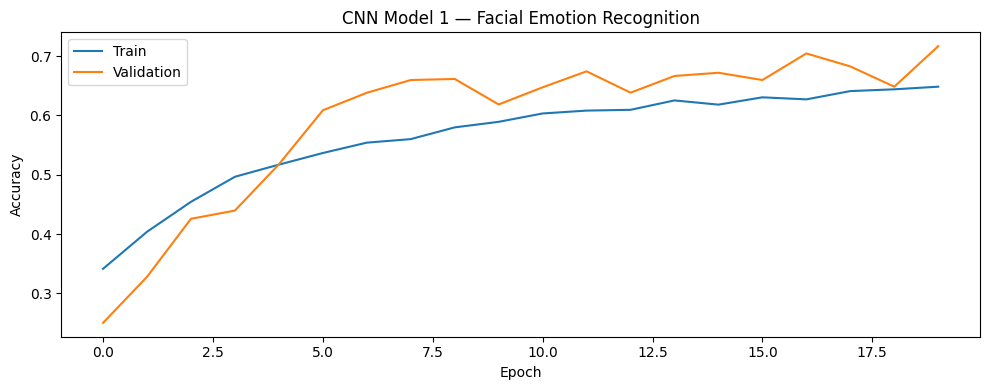

In [29]:
def plot_accuracy(history, title='Training vs Validation Accuracy'):
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['accuracy'],     label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_accuracy(history_1, title='CNN Model 1 — Facial Emotion Recognition')